# Create Training Labels from the Critical Mineral Deposits Database

In [20]:

import geopandas as gpd

import sys
if sys.version_info < (3, 9):
    from importlib_resources import files
else:
    from importlib.resources import files

from beak.experimental.io import load_dataset
from beak.experimental.conversions import create_binary_raster

import numpy as np
import pandas as pd
from shapely.wkt import loads
import rasterio


# Definitions

In [21]:
# Set base paths and files
BASE_PATH = files("beak.data")

EPSG_CODE = 102008
RESOLUTION = 500
BASE_SPATIAL = str(EPSG_CODE) + "_" + str(RESOLUTION)
BASE_EXTENT = "mama_nico_upmidwest"

BASE_RASTER = BASE_PATH / "BASE_RASTERS" / str("EPSG_" + str(EPSG_CODE) + "_RES_" + str(RESOLUTION) + "_" + BASE_EXTENT + ".tif")
base_raster = rasterio.open(BASE_RASTER)

# Points file and query to select relevant mineral occurences
PATH_LABELS = BASE_PATH / "RAW" / "mineral_deposits" / "Magmatic_Cobalt_Nickel" / "TA2_Pre_Hack_12M" / "set_20240609" / "nickel_mineral_site_data.csv"
SQL_QUERY = "country == 'United States'"

# Set the output file
PATH_ROOT = BASE_PATH / "PROCESSED" / str("regional" + "_" + BASE_EXTENT + "_" + BASE_SPATIAL)
PATH_EXPORT = PATH_ROOT / "labels" / str("TA2_240609_FILTERED" + ".tif")
OUT_FILE = PATH_EXPORT

print(f"Output file: {OUT_FILE}")


Output file: S:\Projekte\20230082_DARPA_CriticalMAAS_TA3\Bearbeitung\GitHub\beak-ta3\src\beak\data\PROCESSED\regional_mama_nico_upmidwest_102008_500\labels\EPSG_102008_RES_500_mama_nico_upmidwest_TA2_240609_FILTERED.tif


# **Helper**

In [22]:
import matplotlib.pyplot as plt
def plot_histogram(df, column, num_bins=100):
    df['top1_deposit_classification_confidence'].hist(bins=num_bins)
    plt.xlabel(column)
    plt.ylabel('Frequency')
    plt.title(f"Histogram of {column}")
    plt.show()

In [23]:
def count_values(df, column):    
    values = df[column].unique()
    values_df = pd.DataFrame(values, columns=[column])
    counts = df[column].value_counts()
    values_with_counts = counts.reset_index()
    values_with_counts.columns = [column, 'count']
    
    return values_with_counts


# **Load and initially clean data**

In [24]:
mineral_sites = gpd.read_file(PATH_LABELS)

mineral_sites = load_dataset(PATH_LABELS).query(SQL_QUERY)
mineral_sites = mineral_sites.dropna(subset=["loc_wkt"])
mineral_sites["geometry"] = mineral_sites["loc_wkt"].apply(loads)
mineral_sites = gpd.GeoDataFrame(mineral_sites, geometry="geometry")
mineral_sites = mineral_sites.explode(ignore_index=True)
mineral_sites = mineral_sites.drop_duplicates(subset=["geometry"])
mineral_sites = mineral_sites.set_crs("EPSG:4326")

mineral_sites

,group_id,ms,ms_name,ms_type,ms_rank,country,state_or_province,loc_crs,loc_wkt,top1_deposit_type,top1_deposit_group,top1_deposit_environment,top1_deposit_classification_confidence,top1_deposit_classification_source,geometry
0,6,['https://minmod.isi.edu/resource/site__api-cd...,['NI 43-101 Technical Report (PEA) for the Tam...,NaN,NaN,United States,Minnesota,EPSG:4326,POINT(-93.157 46.700),Komatiite nickel-copper-PGE,Komatiite,Magmatic,0.50000,Inferlink Extraction v2,POINT (-93.15700 46.70000)
1,75,['https://minmod.isi.edu/resource/site__w3id-o...,['NI 43-101 Technical Report on the Maturi Bir...,NaN,NaN,United States,Minnesota,EPSG:4326,GEOMETRYCOLLECTION (MULTIPOINT (-91.7083329999...,U-M layered intrusion nickel- copper-PGE,Ultramafic and (or) mafic-layered intrusion,Magmatic,1.00000,SME,"MULTIPOINT ((-91.70833 47.69694), (-91.79167 4..."
2,75,['https://minmod.isi.edu/resource/site__w3id-o...,['NI 43-101 Technical Report on the Maturi Bir...,NaN,NaN,United States,Minnesota,EPSG:4326,GEOMETRYCOLLECTION (MULTIPOINT (-91.7083329999...,U-M layered intrusion nickel- copper-PGE,Ultramafic and (or) mafic-layered intrusion,Magmatic,1.00000,SME,POINT (-91.80000 47.73333)
3,78,['https://minmod.isi.edu/resource/site__mrdata...,"['Dunka Pit Cu-Ni deposit', 'NI 43-101 Technic...","['Occurrence', 'Unknown']",B,United States,Minnesota,EPSG:4326,GEOMETRYCOLLECTION (MULTIPOINT (-91.7083300000...,U-M layered intrusion nickel- copper-PGE,Ultramafic and (or) mafic-layered intrusion,Magmatic,1.00000,"algorithm predictions, SRI crosswalk agent v0","MULTIPOINT ((-91.70833 47.78333), (-91.79167 4..."
4,78,['https://minmod.isi.edu/resource/site__mrdata...,"['Dunka Pit Cu-Ni deposit', 'NI 43-101 Technic...","['Occurrence', 'Unknown']",B,United States,Minnesota,EPSG:4326,GEOMETRYCOLLECTION (MULTIPOINT (-91.7083300000...,U-M layered intrusion nickel- copper-PGE,Ultramafic and (or) mafic-layered intrusion,Magmatic,1.00000,"algorithm predictions, SRI crosswalk agent v0",POINT (-91.82434 47.72083)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1271,50091,https://minmod.isi.edu/resource/site__mrdata-u...,Warm Springs Creek Area,Past Producer,B,United States,Montana,EPSG:4326,POINT (-111.95805 45.0405),Phosphorite,Phosphorite,Basin chemical,0.57191,"algorithm predictions, SRI deposit type classi...",POINT (-111.95805 45.04050)
1272,13655,https://minmod.isi.edu/resource/site__mrdata-u...,Black Diamond,Prospect,C,United States,Montana,EPSG:4326,POINT (-110.2744 45.25912),U-M layered intrusion PGE,Ultramafic and (or) mafic-layered intrusion,Magmatic,0.28147,"algorithm predictions, SRI deposit type classi...",POINT (-110.27440 45.25912)
1273,50117,https://minmod.isi.edu/resource/site__mrdata-u...,Mount Fleecer-Jerry Creek Area,Prospect,C,United States,Montana,EPSG:4326,POINT (-112.83619 45.8282),Phosphorite,Phosphorite,Basin chemical,0.48519,"algorithm predictions, SRI deposit type classi...",POINT (-112.83619 45.82820)
1274,50129,https://minmod.isi.edu/resource/site__mrdata-u...,Wise River-Johnson Creek Area,Prospect,C,United States,Montana,EPSG:4326,POINT (-112.957 45.82409),Phosphorite,Phosphorite,Basin chemical,0.40002,"algorithm predictions, SRI deposit type classi...",POINT (-112.95700 45.82409)


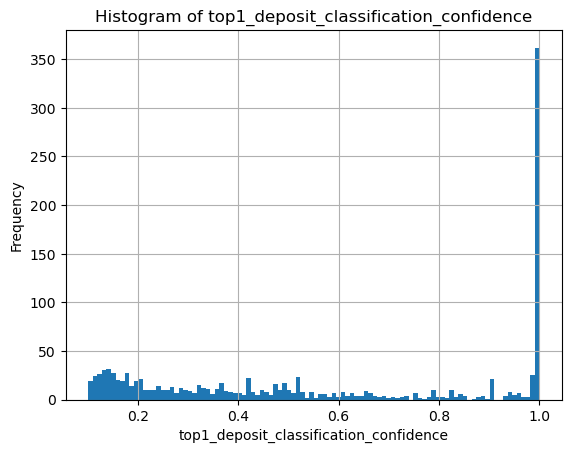

In [25]:
plot_histogram(mineral_sites, "top1_deposit_classification_confidence")

# Export to GeoPackages
## All Points

In [26]:
out_file = str(PATH_LABELS.parent / str(PATH_LABELS.stem)) + ".gpkg"


In [27]:
mineral_sites.to_file(out_file, layer="mineral_sites", driver="GPKG")


## Filtered Points

In [28]:
query = "top1_deposit_type in ('U-M layered intrusion nickel- copper-PGE','U-M intrusion nickel-copper- PGE','U-M conduit nickel-copper- PGE') and top1_deposit_classification_confidence >= 0.5 and ms_type in ('Past Producer', 'Prospect', 'Producer') and ms_rank in ('A', 'B', 'C')"

mineral_sites_filtered = mineral_sites.query(query)
mineral_sites_filtered

,group_id,ms,ms_name,ms_type,ms_rank,country,state_or_province,loc_crs,loc_wkt,top1_deposit_type,top1_deposit_group,top1_deposit_environment,top1_deposit_classification_confidence,top1_deposit_classification_source,geometry
264,6658,https://minmod.isi.edu/resource/site__mrdata-u...,"['Spruce Open Pit Inco', 'Spruce Road deposit']",Prospect,A,United States,Minnesota,EPSG:4326,POINT (-91.681 47.82972),U-M layered intrusion nickel- copper-PGE,Ultramafic and (or) mafic-layered intrusion,Magmatic,1.0,"algorithm predictions, SRI crosswalk agent v0",POINT (-91.68100 47.82972)
265,6675,https://minmod.isi.edu/resource/site__mrdata-u...,Minnamax Cu-Ni Prospect,Prospect,A,United States,Minnesota,EPSG:4326,POINT (-91.88323 47.63166),U-M layered intrusion nickel- copper-PGE,Ultramafic and (or) mafic-layered intrusion,Magmatic,1.0,"algorithm predictions, SRI crosswalk agent v0",POINT (-91.88323 47.63166)
396,9207,https://minmod.isi.edu/resource/site__mrdata-u...,South Filson Creek deposit,Prospect,B,United States,Minnesota,EPSG:4326,POINT (-91.67378 47.82167),U-M layered intrusion nickel- copper-PGE,Ultramafic and (or) mafic-layered intrusion,Magmatic,1.0,"algorithm predictions, SRI crosswalk agent v0",POINT (-91.67378 47.82167)
397,9208,https://minmod.isi.edu/resource/site__mrdata-u...,Wyman Creek deposit,Prospect,B,United States,Minnesota,EPSG:4326,POINT (-92.1074 47.5525),U-M layered intrusion nickel- copper-PGE,Ultramafic and (or) mafic-layered intrusion,Magmatic,1.0,"algorithm predictions, SRI crosswalk agent v0",POINT (-92.10740 47.55250)
480,11784,https://minmod.isi.edu/resource/site__mrdata-u...,Maturi Nokomis Deposit,Prospect,A,United States,Minnesota,EPSG:4326,POINT (-91.75572 47.80138),U-M layered intrusion nickel- copper-PGE,Ultramafic and (or) mafic-layered intrusion,Magmatic,1.0,"algorithm predictions, SRI crosswalk agent v0",POINT (-91.75572 47.80138)
484,12127,['https://minmod.isi.edu/resource/site__10-538...,"['Dunka Road', 'Dunka Road (underground)']",Prospect,A,United States,Minnesota,EPSG:4326,POINT (-91.9004 47.6656),U-M layered intrusion nickel- copper-PGE,Ultramafic and (or) mafic-layered intrusion,Magmatic,1.0,"algorithm predictions, SRI crosswalk agent v0",POINT (-91.90040 47.66560)
821,25803,['https://minmod.isi.edu/resource/site__10-538...,Birch Lake,Prospect,A,United States,Minnesota,EPSG:4326,GEOMETRYCOLLECTION (POINT (-91.799999999999997...,U-M layered intrusion nickel- copper-PGE,Ultramafic and (or) mafic-layered intrusion,Magmatic,1.0,"algorithm predictions, SRI crosswalk agent v0",POINT (-91.80000 47.75000)
822,25803,['https://minmod.isi.edu/resource/site__10-538...,Birch Lake,Prospect,A,United States,Minnesota,EPSG:4326,GEOMETRYCOLLECTION (POINT (-91.799999999999997...,U-M layered intrusion nickel- copper-PGE,Ultramafic and (or) mafic-layered intrusion,Magmatic,1.0,"algorithm predictions, SRI crosswalk agent v0",POINT (-91.81794 47.75027)
918,29419,https://minmod.isi.edu/resource/site__mrdata-u...,Unnamed (North Crillon Glacier),Prospect,C,United States,Alaska,EPSG:4326,POINT (-137.31212 58.65971),U-M layered intrusion nickel- copper-PGE,Ultramafic and (or) mafic-layered intrusion,Magmatic,1.0,"algorithm predictions, SRI crosswalk agent v0",POINT (-137.31212 58.65971)


In [29]:
labels = mineral_sites_filtered.to_crs(base_raster.crs)


# Create Labels

In [30]:
data = labels.copy()
data = data.explode(ignore_index=True)
data = data[~data.is_empty]
data = data.reset_index(drop=True)
data = data.to_crs(base_raster.crs)


In [31]:
labels_array = create_binary_raster(data, base_raster, all_touched=False, same_shape=True, fill_negatives=True, out_file=PATH_EXPORT)
print(f"Number of positive training labels: {np.sum(labels_array==1)}")

Number of positive training labels: 8
